In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('2019-Nov_smartphone_preprocessed_final.csv')

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,is_price_error,hour,day_of_week,day_name,time_segment,is_outlier,is_purchase,is_cart
0,2019-11-01 09:00:00,view,1003461,-1769995873,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33,False,9,4,Friday,오전 (6-12시),False,0,0
1,2019-11-01 09:00:01,view,1004775,-1769995873,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2,False,9,4,Friday,오전 (6-12시),False,0,0
2,2019-11-01 09:00:02,view,1004258,-1769995873,electronics.smartphone,apple,732.07,532647354,d2d3d2c6-631d-489e-9fb5-06f340b85be0,False,9,4,Friday,오전 (6-12시),False,0,0
3,2019-11-01 09:00:07,view,1004566,-1769995873,electronics.smartphone,huawei,164.84,566265908,52c2c76c-b79e-4794-86ff-badc76d35f5a,False,9,4,Friday,오전 (6-12시),False,0,0
4,2019-11-01 09:00:08,view,1004708,-1769995873,electronics.smartphone,huawei,151.99,566143627,aa610ab3-5c60-4551-8a2b-8c999dddf843,False,9,4,Friday,오전 (6-12시),False,0,0


In [2]:
df = df.sort_values(['user_session', 'event_time']).copy()

In [3]:
grouped = df.groupby(['user_session', 'product_id'])

In [4]:
event_first_time = (
    df
    .groupby(['user_session', 'product_id', 'event_type'])['event_time']
    .min()
    .unstack()
    .reset_index()
)

for col in ['view', 'cart', 'purchase']:
    if col not in event_first_time.columns:
        event_first_time[col] = pd.NaT

# 존재 여부 컬럼 따로 생성
event_first_time['has_view'] = event_first_time['view'].notna()
event_first_time['has_cart'] = event_first_time['cart'].notna()
event_first_time['has_purchase'] = event_first_time['purchase'].notna()

# 순서 검증
event_first_time['view_to_cart'] = (
    event_first_time['has_view'] &
    event_first_time['has_cart'] &
    (event_first_time['view'] < event_first_time['cart'])
)

event_first_time['view_to_cart_to_purchase'] = (
    event_first_time['has_view'] &
    event_first_time['has_cart'] &
    event_first_time['has_purchase'] &
    (event_first_time['view'] < event_first_time['cart']) &
    (event_first_time['cart'] < event_first_time['purchase'])
)

funnel_df = event_first_time[[
    'user_session',
    'product_id',
    'has_view',
    'view_to_cart',
    'view_to_cart_to_purchase'
]].rename(columns={
    'has_view': 'view'
})

In [5]:
funnel_summary = pd.DataFrame({
    'step': ['view', 'view_to_cart', 'view_to_cart_to_purchase'],
    'count': [
        funnel_df['view'].sum(),
        funnel_df['view_to_cart'].sum(),
        funnel_df['view_to_cart_to_purchase'].sum()
    ]
})

funnel_summary['conversion_rate_vs_view'] = (
    funnel_summary['count'] / funnel_summary.loc[0, 'count'] * 100
)

funnel_summary

,step,count,conversion_rate_vs_view
0,view,9566596,100.000000
1,view_to_cart,738409,7.718618
2,view_to_cart_to_purchase,299642,3.132169


In [6]:
view_sessions = funnel_df['view'].sum()
view_to_cart_sessions = funnel_df['view_to_cart'].sum()
view_to_cart_to_purchase_sessions = funnel_df['view_to_cart_to_purchase'].sum()

view_to_cart_rate = view_to_cart_sessions / view_sessions
cart_to_purchase_rate = view_to_cart_to_purchase_sessions / view_to_cart_sessions
total_conversion_rate = view_to_cart_to_purchase_sessions / view_sessions

In [7]:
target_brands = ['samsung', 'apple', 'xiaomi']

df_flow = df[df['brand'].isin(target_brands)].copy()
df_flow = df_flow.sort_values(['user_session', 'event_time'])

flow_df = (
    df_flow[df_flow['event_type'].isin(['view', 'cart', 'purchase'])]
    .groupby(['user_session', 'event_type'])['brand']
    .first()
    .unstack()
    .reset_index()
)

flow_df = flow_df.rename(columns={
    'view': 'view_brand',
    'cart': 'cart_brand',
    'purchase': 'purchase_brand'
})

flow_df.head()

event_type,user_session,cart_brand,purchase_brand,view_brand
0,0000009d-1f5b-40b9-bd23-db4f3d973ae3,NaN,NaN,apple
1,00000616-f016-4c01-b323-438486d9d3ee,NaN,NaN,apple
2,000009c4-a1dd-4764-87d9-24f3d7e43c4f,NaN,NaN,apple
3,00000c2a-aada-4ee8-a0ae-1948795f4d34,NaN,NaN,samsung
4,000015e0-0fe1-440b-9d4b-1395cef84f38,NaN,NaN,apple


In [8]:
def classify_flow(row):
    v = row.get('view_brand')
    c = row.get('cart_brand')
    p = row.get('purchase_brand')

    brands = [x for x in [v, c, p] if pd.notna(x)]

    if pd.isna(v) or pd.isna(p):
        return 'no_purchase_or_no_view'

    if pd.notna(c):
        if v == c == p:
            return 'same_brand'
        elif v != c and c == p:
            return 'view_to_cart_switch'
        elif v == c and c != p:
            return 'cart_to_purchase_switch'
        elif len(set(brands)) == 3:
            return 'multi_brand_exploration'
        else:
            return 'etc'
    else:
        if v == p:
            return 'direct_same_purchase'
        else:
            return 'direct_switch_purchase'

flow_df['pattern'] = flow_df.apply(classify_flow, axis=1)

flow_df['pattern'].value_counts()

pattern
no_purchase_or_no_view     3442313
same_brand                  239413
direct_same_purchase         31377
view_to_cart_switch           9833
direct_switch_purchase        1262
cart_to_purchase_switch       1194
etc                            396
multi_brand_exploration         31
Name: count, dtype: int64

In [9]:
flow_df['pattern'].value_counts(normalize=True) * 100

pattern
no_purchase_or_no_view     92.390774
same_brand                  6.425782
direct_same_purchase        0.842150
view_to_cart_switch         0.263915
direct_switch_purchase      0.033872
cart_to_purchase_switch     0.032047
etc                         0.010629
multi_brand_exploration     0.000832
Name: proportion, dtype: float64

view -> cart 변경

In [10]:
vc_switch = flow_df[flow_df['pattern'] == 'view_to_cart_switch'].copy()

vc_matrix = (
    vc_switch.groupby(['view_brand', 'cart_brand'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

vc_matrix

,view_brand,cart_brand,count
3,samsung,xiaomi,2973
0,apple,samsung,2720
2,samsung,apple,2205
5,xiaomi,samsung,1039
1,apple,xiaomi,660
4,xiaomi,apple,236


cart -> purchase 변경

In [11]:
cp_switch = flow_df[flow_df['pattern'] == 'cart_to_purchase_switch'].copy()

cp_matrix = (
    cp_switch.groupby(['cart_brand', 'purchase_brand'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

cp_matrix

,cart_brand,purchase_brand,count
0,apple,samsung,381
3,samsung,xiaomi,339
2,samsung,apple,259
5,xiaomi,samsung,140
1,apple,xiaomi,52
4,xiaomi,apple,23


view -> X -> purchase

In [12]:
dp_switch = flow_df[flow_df['pattern'] == 'direct_switch_purchase'].copy()

dp_matrix = (
    dp_switch.groupby(['view_brand', 'purchase_brand'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

dp_matrix

,view_brand,purchase_brand,count
3,samsung,xiaomi,382
2,samsung,apple,319
0,apple,samsung,308
5,xiaomi,samsung,128
1,apple,xiaomi,97
4,xiaomi,apple,28


같은 브랜드를 구매하는 시간 소요 = 브랜드 관여 정도

In [13]:
# view / purchase 시간 + 브랜드 추출
event_time_df = (
    df[df['event_type'].isin(['view', 'purchase'])]
    .sort_values(['user_session', 'event_time'])
)

event_time_pivot = (
    event_time_df
    .groupby(['user_session', 'event_type'])
    .agg({
        'event_time': 'first',
        'brand': 'first'
    })
    .unstack()
)

# 컬럼 정리
event_time_pivot.columns = [
    f"{col[0]}_{col[1]}" for col in event_time_pivot.columns
]

event_time_pivot = event_time_pivot.reset_index()

event_time_pivot.head()

,user_session,event_time_purchase,event_time_view,brand_purchase,brand_view
0,0000009d-1f5b-40b9-bd23-db4f3d973ae3,NaN,2019-11-13 15:02:54,NaN,apple
1,000001d5-f8f8-4e40-b8d6-224155713521,NaN,2019-11-09 22:58:06,NaN,honor
2,00000616-f016-4c01-b323-438486d9d3ee,NaN,2019-11-17 14:36:28,NaN,apple
3,000009c4-a1dd-4764-87d9-24f3d7e43c4f,NaN,2019-11-02 04:06:53,NaN,apple
4,00000c2a-aada-4ee8-a0ae-1948795f4d34,NaN,2019-12-01 03:15:47,NaN,samsung


In [14]:
# event_time datetime 변환
df['event_time'] = pd.to_datetime(df['event_time'], errors='coerce')

# 다시 pivot 생성
event_time_df = (
    df[df['event_type'].isin(['view', 'purchase'])]
    .sort_values(['user_session', 'event_time'])
)

event_time_pivot = (
    event_time_df
    .groupby(['user_session', 'event_type'])
    .agg({
        'event_time': 'first',
        'brand': 'first'
    })
    .unstack()
)

event_time_pivot.columns = [
    f"{col[0]}_{col[1]}" for col in event_time_pivot.columns
]

event_time_pivot = event_time_pivot.reset_index()

# 혹시 모를 문자열 방지
event_time_pivot['event_time_view'] = pd.to_datetime(
    event_time_pivot['event_time_view'], errors='coerce'
)

event_time_pivot['event_time_purchase'] = pd.to_datetime(
    event_time_pivot['event_time_purchase'], errors='coerce'
)

# 구매 도달 시간 계산
event_time_pivot['time_to_purchase_sec'] = (
    event_time_pivot['event_time_purchase'] - event_time_pivot['event_time_view']
).dt.total_seconds()

event_time_pivot['time_to_purchase_hour'] = (
    event_time_pivot['time_to_purchase_sec'] / 3600
)

event_time_pivot.head()

,user_session,event_time_purchase,event_time_view,brand_purchase,brand_view,time_to_purchase_sec,time_to_purchase_hour
0,0000009d-1f5b-40b9-bd23-db4f3d973ae3,NaT,2019-11-13 15:02:54,NaN,apple,NaN,NaN
1,000001d5-f8f8-4e40-b8d6-224155713521,NaT,2019-11-09 22:58:06,NaN,honor,NaN,NaN
2,00000616-f016-4c01-b323-438486d9d3ee,NaT,2019-11-17 14:36:28,NaN,apple,NaN,NaN
3,000009c4-a1dd-4764-87d9-24f3d7e43c4f,NaT,2019-11-02 04:06:53,NaN,apple,NaN,NaN
4,00000c2a-aada-4ee8-a0ae-1948795f4d34,NaT,2019-12-01 03:15:47,NaN,samsung,NaN,NaN


In [15]:
purchase_time_df = event_time_pivot[
    event_time_pivot['event_time_view'].notna() &
    event_time_pivot['event_time_purchase'].notna()
].copy()

In [16]:
purchase_time_by_brand = (
    purchase_time_df.groupby('brand_purchase')
    .agg(
        avg_time=('time_to_purchase_hour', 'mean'),
        median_time=('time_to_purchase_hour', 'median'),
        count=('time_to_purchase_hour', 'count')
    )
    .reset_index()
    .sort_values('avg_time')
)

purchase_time_by_brand

,brand_purchase,avg_time,median_time,count
13,irbis,0.036071,0.031111,7
22,philips,0.055556,0.055556,1
7,google,0.068763,0.041944,31
19,nubia,0.070764,0.053472,4
0,apple,0.076664,0.033889,107052
28,tp-link,0.091496,0.041389,442
24,samsung,0.092373,0.044167,134093
5,fly,0.093768,0.066944,23
10,htc,0.095453,0.037639,38
12,inoi,0.107602,0.049722,164


view 기준 다른 브랜드 구매 or 같은 브랜드 구매

In [17]:
same_brand_df = purchase_time_df[
    purchase_time_df['brand_view'] == purchase_time_df['brand_purchase']
].copy()

same_brand_time = (
    same_brand_df.groupby('brand_purchase')
    .agg(
        avg_time=('time_to_purchase_hour', 'mean'),
        median_time=('time_to_purchase_hour', 'median'),
        count=('time_to_purchase_hour', 'count')
    )
    .reset_index()
    .sort_values('avg_time')
)

same_brand_time

,brand_purchase,avg_time,median_time,count
13,irbis,0.012986,0.007917,4
2,blackberry,0.034786,0.026111,13
14,jinga,0.046389,0.029028,8
10,htc,0.048356,0.029444,25
25,tecno,0.052117,0.033333,53
27,tp-link,0.052806,0.033056,340
8,haier,0.056033,0.038889,25
5,fly,0.056639,0.021944,10
29,unknown,0.058805,0.036250,86
32,zte,0.061479,0.035556,43


In [18]:
purchase_time_df['same_brand'] = (
    purchase_time_df['brand_view'] == purchase_time_df['brand_purchase']
)

compare_time = (
    purchase_time_df.groupby(['brand_purchase', 'same_brand'])
    .agg(
        avg_time=('time_to_purchase_hour', 'mean'),
        median_time=('time_to_purchase_hour', 'median'),
        count=('time_to_purchase_hour', 'count')
    )
    .reset_index()
)

compare_time

,brand_purchase,same_brand,avg_time,median_time,count
0,apple,False,0.210319,0.074722,3367
1,apple,True,0.072324,0.033056,103685
2,asus,False,0.923056,0.923056,1
3,asus,True,0.095031,0.056389,9
4,blackberry,False,0.649259,0.122222,3
...,...,...,...,...,...
61,vivo,True,0.073808,0.038056,1292
62,xiaomi,False,0.272752,0.135556,6160
63,xiaomi,True,0.117414,0.050278,35166
64,zte,False,0.164925,0.101944,37


In [19]:
target_brands = ['samsung', 'apple', 'xiaomi']

purchase_time_by_brand = purchase_time_by_brand[
    purchase_time_by_brand['brand_purchase'].isin(target_brands)
]

same_brand_time = same_brand_time[
    same_brand_time['brand_purchase'].isin(target_brands)
]

compare_time = compare_time[
    compare_time['brand_purchase'].isin(target_brands)
]

In [20]:
# 전체 vs 동일 브랜드 비교
final_time_compare = purchase_time_by_brand.merge(
    same_brand_time,
    on='brand_purchase',
    suffixes=('_all', '_same')
)

# 보기 좋게 정리
final_time_compare = final_time_compare[
    [
        'brand_purchase',
        'avg_time_all', 'median_time_all',
        'avg_time_same', 'median_time_same',
        'count_all', 'count_same'
    ]
]

# 차이 계산
final_time_compare['time_diff'] = (
    final_time_compare['avg_time_all'] - final_time_compare['avg_time_same']
)

final_time_compare.sort_values('avg_time_all')

,brand_purchase,avg_time_all,median_time_all,avg_time_same,median_time_same,count_all,count_same,time_diff
0,apple,0.076664,0.033889,0.072324,0.033056,107052,103685,0.004340
1,samsung,0.092373,0.044167,0.087546,0.042500,134093,127735,0.004827
2,xiaomi,0.140568,0.058611,0.117414,0.050278,41326,35166,0.023155


In [21]:
# same_brand True/False를 보기 좋게
compare_time_pivot = compare_time.pivot(
    index='brand_purchase',
    columns='same_brand',
    values='avg_time'
).reset_index()

compare_time_pivot.columns = [
    'brand',
    'cross_purchase_time',  # False
    'same_brand_time'       # True
]

# 차이 계산
compare_time_pivot['diff'] = (
    compare_time_pivot['cross_purchase_time'] -
    compare_time_pivot['same_brand_time']
)

compare_time_pivot.sort_values('cross_purchase_time')

,brand,cross_purchase_time,same_brand_time,diff
1,samsung,0.189349,0.087546,0.101803
0,apple,0.210319,0.072324,0.137995
2,xiaomi,0.272752,0.117414,0.155339


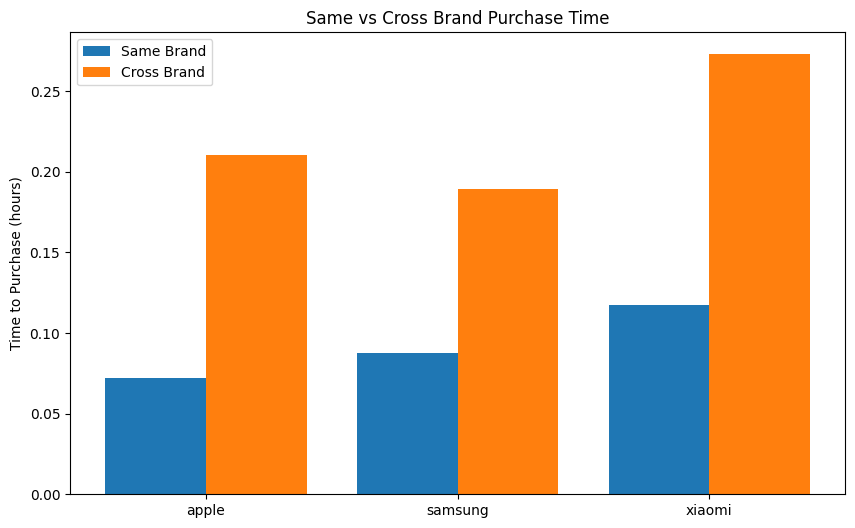

In [22]:
import matplotlib.pyplot as plt

x = range(len(compare_time_pivot))

plt.figure(figsize=(10,6))

plt.bar(
    [i - 0.2 for i in x],
    compare_time_pivot['same_brand_time'],
    width=0.4,
    label='Same Brand'
)

plt.bar(
    [i + 0.2 for i in x],
    compare_time_pivot['cross_purchase_time'],
    width=0.4,
    label='Cross Brand'
)

plt.xticks(x, compare_time_pivot['brand'])
plt.ylabel('Time to Purchase (hours)')
plt.title('Same vs Cross Brand Purchase Time')
plt.legend()

plt.show()